# 04 · Modeling: Shipment Delay Prediction

**Goal:** predict the probability that a shipment is delivered late (`is_delayed`) and score every shipment for the Power BI dashboard.

**Models:** Random Forest and XGBoost only (the EDA plots show non-linear, interaction-heavy signal that tree models handle well).

**Method**
1. Split by time first (oldest 80% = train, newest 20% = test). The test set is used once, at the end.
2. All preprocessing lives inside an sklearn `Pipeline`, so nothing is fitted on test rows.
3. Class imbalance is handled with `class_weight` / `scale_pos_weight` (no SMOTE).
4. Hyper-parameters are tuned with time-ordered cross-validation (`TimeSeriesSplit`).
5. The decision threshold is chosen on out-of-fold training predictions, never on the test set.
6. Power BI output uses out-of-fold probabilities (+ test-set predictions), so no row is scored by a model that trained on it.

**Metrics:** ROC-AUC, PR-AUC, F1 / precision / recall at the chosen threshold, and **RMSE** of the predicted delay probability vs the actual 0/1 outcome (= square root of the Brier score; lower is better).

**Notebook map**

| # | Section | Output |
|---|---------|--------|
| 1 | Setup | libraries, random seed |
| 2 | Load data and guard against leakage | candidate feature list |
| 3 | Stateless preparation | sorted, cleaned dataframe |
| 4 | Time-based train / test split | train and test sets |
| 5 | Preprocessing pipeline and feature check | final feature list |
| 6 | Baseline benchmark of RF and XGBoost | model ranking |
| 7 | Tune Random Forest and XGBoost | best hyper-parameters |
| 8 | Out-of-fold probabilities, calibration, threshold | calibrated scores and thresholds |
| 9 | Results: train (OOF) vs test | metrics table, confusion matrices, selected model |
| 10 | Plots | precision-recall, calibration, feature importance |
| 11 | Chronological back-test | stability across time windows |
| 12 | Power BI file | `powerbi_delay_risk.csv` |
| 13 | Save the model for the Streamlit app | `model_artifacts/delay_model.joblib` |
| 14 | Summary | conclusions and caveats |

## 1. Setup

In [ ]:
import warnings
from pathlib import Path
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

import sklearn
import xgboost
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression   # used only as the Platt calibrator (Section 8)
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score, precision_score,
                             recall_score, confusion_matrix, brier_score_loss,
                             mean_squared_error, precision_recall_curve)
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
SEED = 42

## 2. Load data and guard against leakage

Columns that reveal the outcome (delay days, delivery dates, supplier scores) and free-text columns are excluded from the features.

In [2]:

PROCESSED_DATA_PATH = (
    Path("..") / "data" / "processed_data" / "scms_clean.pkl"
)

df = pd.read_pickle(PROCESSED_DATA_PATH)

TARGET = "is_delayed"

LEAKAGE = [
    "delay_days",
    "Delivered to Client Date",
    "Delivery Recorded Date",
    "supplier_score",
    "on_time_rate",
    TARGET,
]

TEXT_COLS = [
    "Item Description",
    "Molecule/Test Type",
    "Brand",
    "Dosage",
]

# Do not use target, leakage, free-text, or duplicate-derived columns.
EXCLUDED = set(LEAKAGE + TEXT_COLS + ["Scheduled Delivery Date", "value_per_item"])

selected_features = [
    c for c in df.columns
    if c not in EXCLUDED
]

# These are created later in the notebook.
selected_features += [
    "scheduled_month",
    "scheduled_weekday",
]

print(df.shape, "| candidate features:", len(selected_features))

(10324, 30) | candidate features: 22


## 3. Stateless preparation

Only operations that learn nothing from the data: sorting by date, calendar features, type fixes, and a separate `Unknown` level for missing categories.

In [3]:
# Sort by scheduled date so 'first 80%' really means 'oldest 80%'
df = df.sort_values("Scheduled Delivery Date", kind="mergesort").reset_index(drop=True)

df["scheduled_month"] = df["Scheduled Delivery Date"].dt.month
df["scheduled_weekday"] = df["Scheduled Delivery Date"].dt.weekday
df["is_delayed"] = df["is_delayed"].astype(int)
df = df.replace([np.inf, -np.inf], np.nan)          # e.g. cost_per_kg when weight is 0

# Missing category = its own level
cat_all = [c for c in selected_features if not pd.api.types.is_numeric_dtype(df[c])]
for c in cat_all:
    df[c] = df[c].astype(object).where(df[c].notna(), "Unknown")

## 4. Time-based train / test split

Oldest 80% of shipments = train, newest 20% = test. `TimeSeriesSplit` (5 folds) is used for all cross-validation on the training data.

In [4]:
TEST_FRAC = 0.20
split = int(len(df) * (1 - TEST_FRAC))

train_df = df.iloc[:split].copy()
test_df = df.iloc[split:].copy()

y_train = train_df["is_delayed"]
y_test = test_df["is_delayed"]

print("Overall delay rate:", df["is_delayed"].mean())
print("Train delay rate:", y_train.mean())
print("Test delay rate:", y_test.mean())

print("\nTrain class counts:")
print(y_train.value_counts())

print("\nTest class counts:")
print(y_test.value_counts())

cv = TimeSeriesSplit(n_splits=5)

Overall delay rate: 0.11487795428128632
Train delay rate: 0.11127255115631432
Test delay rate: 0.12929782082324456

Train class counts:
is_delayed
0    7340
1     919
Name: count, dtype: int64

Test class counts:
is_delayed
0    1798
1     267
Name: count, dtype: int64


## 5. Preprocessing pipeline and feature check

The EDA plots showed that *First Line Designation*, *Managed By*, the two `*_missing` flags and `scheduled_weekday` carry almost no signal.
Instead of just assuming it, the cell below compares time-ordered CV PR-AUC with and without them (training data only) and keeps the smaller set unless it loses accuracy.

In [5]:
def make_pipeline(model, cols):
    cat = [c for c in cols if c in cat_all]
    num = [c for c in cols if c not in cat]
    prep = ColumnTransformer([
        ("num", SimpleImputer(strategy="median"), num),
        # categories seen in < 50 training rows are pooled into one 'infrequent' level
        ("cat", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=50,
                              sparse_output=False), cat),
    ])
    return Pipeline([("prep", prep), ("model", model)])

LOW_SIGNAL = ["First Line Designation", "Managed By", "weight_missing", "freight_missing", "scheduled_weekday"]
FULL_SET = list(selected_features)
REDUCED_SET = [c for c in FULL_SET if c not in LOW_SIGNAL]

probe = RandomForestClassifier(n_estimators=200, min_samples_leaf=5, class_weight="balanced",
                               random_state=SEED, n_jobs=-1)

def cv_pr_auc(cols):
    scores = []
    for tr, va in cv.split(train_df):
        m = make_pipeline(clone(probe), cols).fit(train_df.iloc[tr][cols], y_train.iloc[tr])
        scores.append(average_precision_score(y_train.iloc[va], m.predict_proba(train_df.iloc[va][cols])[:, 1]))
    return np.mean(scores)

s_full, s_red = cv_pr_auc(FULL_SET), cv_pr_auc(REDUCED_SET)
FEATURES = REDUCED_SET if s_red >= s_full - 0.005 else FULL_SET
print(f"CV PR-AUC  all {len(FULL_SET)} features: {s_full:.4f} | reduced {len(REDUCED_SET)} features: {s_red:.4f}")
print(f"Using {len(FEATURES)} features:", FEATURES)

CV PR-AUC  all 22 features: 0.1807 | reduced 19 features: 0.1834
Using 19 features: ['Country', 'Fulfill Via', 'Vendor INCO Term', 'Shipment Mode', 'Product Group', 'Sub Classification', 'Vendor', 'Dosage Form', 'Unit of Measure (Per Pack)', 'Line Item Quantity', 'Line Item Value', 'Pack Price', 'Unit Price', 'Manufacturing Site', 'Weight (Kilograms)', 'Freight Cost (USD)', 'Line Item Insurance (USD)', 'cost_per_kg', 'scheduled_month']


## 6. Baseline benchmark: Random Forest vs XGBoost

A quick, like-for-like comparison of the two untuned models on the training data only, using time-ordered out-of-fold predictions, class-imbalance weighting and one fixed threshold (0.14). Models are ranked by PR-AUC.

Scores here cover **all** CV folds, including the early folds where every model is weak (see Section 8), so they are lower than the Section 9 figures.

**Reading the table:** Random Forest has the higher PR-AUC (0.207 vs 0.196) and XGBoost flags more shipments at the same threshold. Both are carried forward to tuning.

In [6]:
# ---------------------------------------------------
# 1. Create the preprocessing pipeline
# ---------------------------------------------------

def create_model_pipeline(model):

    categorical_columns = []
    numeric_columns = []

    for column in FEATURES:
        if column in cat_all:
            categorical_columns.append(column)
        else:
            numeric_columns.append(column)

    numeric_preprocessing = SimpleImputer(
        strategy="median"
    )

    categorical_preprocessing = Pipeline([
        ("fill_missing", SimpleImputer(
            strategy="constant",
            fill_value="Unknown"
        )),
        ("one_hot_encoding", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ])

    preprocessor = ColumnTransformer([
        ("numeric", numeric_preprocessing, numeric_columns),
        ("categorical", categorical_preprocessing, categorical_columns)
    ])

    complete_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    return complete_pipeline


# ---------------------------------------------------
# 2. Calculate the imbalance weight
# ---------------------------------------------------

delayed_count = y_train.sum()
normal_count = len(y_train) - delayed_count

scale_pos_weight = normal_count / delayed_count

print("Delayed shipments:", delayed_count)
print("Normal shipments:", normal_count)
print("Scale positive weight:", round(scale_pos_weight, 2))


# ---------------------------------------------------
# 3. Define the models
# ---------------------------------------------------

models = {

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        tree_method="hist",
        random_state=42,
        n_jobs=-1
    )
}


# ---------------------------------------------------
# 4. Create out-of-fold predictions
# ---------------------------------------------------

def get_oof_predictions(model_pipeline):

    predictions = []
    actual_values = []

    for fold_number, (train_indexes, validation_indexes) in enumerate(
        cv.split(train_df)
    ):

        print("  Running fold:", fold_number + 1)

        model_copy = clone(model_pipeline)

        model_copy.fit(
            train_df.iloc[train_indexes][FEATURES],
            y_train.iloc[train_indexes]
        )

        fold_predictions = model_copy.predict_proba(
            train_df.iloc[validation_indexes][FEATURES]
        )[:, 1]

        predictions.extend(fold_predictions)
        actual_values.extend(
            y_train.iloc[validation_indexes]
        )

    return np.array(actual_values), np.array(predictions)


# ---------------------------------------------------
# 5. Compare the models
# ---------------------------------------------------

comparison_results = []

# One fixed threshold for every model so the comparison is like-for-like
# (0.14 equals the Random Forest threshold chosen later in Section 8).
BENCHMARK_THRESHOLD = 0.14

for model_name, model in models.items():

    print("\nTraining:", model_name)

    model_pipeline = create_model_pipeline(model)

    actual_values, probabilities = get_oof_predictions(
        model_pipeline
    )

    predicted_values = (
        probabilities >= BENCHMARK_THRESHOLD
    ).astype(int)

    result = {
        "Model": model_name,
        "ROC-AUC": roc_auc_score(
            actual_values,
            probabilities
        ),
        "PR-AUC": average_precision_score(
            actual_values,
            probabilities
        ),
        "F1": f1_score(
            actual_values,
            predicted_values,
            zero_division=0
        ),
        "Precision": precision_score(
            actual_values,
            predicted_values,
            zero_division=0
        ),
        "Recall": recall_score(
            actual_values,
            predicted_values,
            zero_division=0
        ),
        "Alert rate": predicted_values.mean()
    }

    comparison_results.append(result)


comparison_results = pd.DataFrame(
    comparison_results
)

comparison_results = comparison_results.sort_values(
    "PR-AUC",
    ascending=False
).reset_index(drop=True)

print("\nModel comparison:")
display(comparison_results.round(4))

Delayed shipments: 919
Normal shipments: 7340
Scale positive weight: 7.99

Training: Random Forest
  Running fold: 1
  Running fold: 2
  Running fold: 3
  Running fold: 4
  Running fold: 5

Training: XGBoost
  Running fold: 1
  Running fold: 2
  Running fold: 3
  Running fold: 4
  Running fold: 5

Model comparison:


,Model,ROC-AUC,PR-AUC,F1,Precision,Recall,Alert rate
0,Random Forest,0.6482,0.2029,0.2535,0.2042,0.3341,0.2121
1,XGBoost,0.6522,0.1933,0.3049,0.2085,0.5673,0.3528


## 7. Tune Random Forest and XGBoost

Randomized search with time-ordered CV, scored on PR-AUC (the metric that suits an imbalanced target).

In [7]:
pos_weight = (1 - y_train.mean()) / y_train.mean()

searches = {
    "RF": RandomizedSearchCV(
        make_pipeline(RandomForestClassifier(class_weight="balanced_subsample", random_state=SEED, n_jobs=-1), FEATURES),
        {"model__n_estimators": [200, 400, 600],
         "model__max_depth": [None, 6, 10, 16],
         "model__min_samples_leaf": [1, 2, 5, 10],
         "model__max_features": ["sqrt", "log2", 0.3]},
        n_iter=12, cv=cv, scoring="average_precision", random_state=SEED, n_jobs=1, refit=True),
    "XGB": RandomizedSearchCV(
        make_pipeline(XGBClassifier(scale_pos_weight=pos_weight, eval_metric="logloss",
                                    tree_method="hist", random_state=SEED, n_jobs=-1), FEATURES),
        {"model__n_estimators": [150, 300, 500],
         "model__max_depth": [3, 4, 5, 6],
         "model__learning_rate": [0.02, 0.05, 0.1],
         "model__subsample": [0.7, 0.85, 1.0],
         "model__colsample_bytree": [0.6, 0.8, 1.0],
         "model__min_child_weight": [1, 3, 5, 10]},
        n_iter=15, cv=cv, scoring="average_precision", random_state=SEED, n_jobs=1, refit=True),
}

for name, s in searches.items():
    s.fit(train_df[FEATURES], y_train)
    print(f"{name}: CV PR-AUC {s.best_score_:.4f} | {s.best_params_}")

RF: CV PR-AUC 0.1838 | {'model__n_estimators': 200, 'model__min_samples_leaf': 1, 'model__max_features': 'log2', 'model__max_depth': None}
XGB: CV PR-AUC 0.1811 | {'model__subsample': 0.85, 'model__n_estimators': 300, 'model__min_child_weight': 5, 'model__max_depth': 3, 'model__learning_rate': 0.05, 'model__colsample_bytree': 0.8}


## 8. Out-of-fold probabilities, calibration and threshold

* Out-of-fold (OOF) = each training row is scored by a model that only saw **earlier** data. The first training window never gets an OOF score.
* The delay pattern changed a lot over time, so models trained on the earliest years predict the next period poorly (see the per-fold table below).
  The calibrator and the threshold are therefore fitted only on folds where the model has real skill (**OOF ROC-AUC >= 0.55**). This rule uses training data only.
* Class weights inflate probabilities, so a Platt (sigmoid) calibrator, fitted on those OOF probabilities, turns scores into real probabilities. This matters for RMSE and for the risk bands.
* The threshold maximises F1 on the calibrated OOF probabilities of the same folds.

In [8]:
MIN_FOLD_AUC = 0.55

def oof_predict(estimator):
    p = np.full(len(train_df), np.nan)
    fold_id = np.full(len(train_df), -1)
    for k, (tr, va) in enumerate(cv.split(train_df)):
        m = clone(estimator).fit(train_df.iloc[tr][FEATURES], y_train.iloc[tr])
        p[va] = m.predict_proba(train_df.iloc[va][FEATURES])[:, 1]
        fold_id[va] = k
    return p, fold_id

def to_logit(p):
    p = np.clip(p, 1e-6, 1 - 1e-6)
    return np.log(p / (1 - p)).reshape(-1, 1)

def best_f1_threshold(y, p):
    grid = np.arange(0.02, 0.90, 0.01)
    f1s = [f1_score(y, (p >= t).astype(int)) for t in grid]
    return float(grid[int(np.argmax(f1s))]), float(max(f1s))

R = {}
for name, s in searches.items():
    oof_raw, fold_id = oof_predict(s.best_estimator_)
    scored = fold_id >= 0

    diag = pd.DataFrame([{"fold": k, "rows": int((fold_id == k).sum()),
                          "delay_rate": y_train[fold_id == k].mean(),
                          "ROC-AUC": roc_auc_score(y_train[fold_id == k], oof_raw[fold_id == k]),
                          "PR-AUC": average_precision_score(y_train[fold_id == k], oof_raw[fold_id == k])}
                         for k in range(cv.n_splits)])
    good_folds = diag.loc[diag["ROC-AUC"] >= MIN_FOLD_AUC, "fold"].tolist() or [cv.n_splits - 1]
    good = np.isin(fold_id, good_folds)
    print(f"\n{name}: per-fold OOF diagnostics (folds used for calibration/threshold: {good_folds})")
    display(diag.round(3))

    platt = LogisticRegression(C=1e6).fit(to_logit(oof_raw[good]), y_train[good])
    oof_cal = np.full_like(oof_raw, np.nan)
    oof_cal[scored] = platt.predict_proba(to_logit(oof_raw[scored]))[:, 1]

    test_raw = s.best_estimator_.predict_proba(test_df[FEATURES])[:, 1]
    test_cal = platt.predict_proba(to_logit(test_raw))[:, 1]

    thr, oof_f1 = best_f1_threshold(y_train[good], oof_cal[good])
    R[name] = dict(oof_raw=oof_raw, oof_cal=oof_cal, fold_id=fold_id, scored=scored, good=good,
                   test_raw=test_raw, test_cal=test_cal, thr=thr, oof_f1=oof_f1)
    print(f"{name}: threshold {thr:.2f} (OOF F1 {oof_f1:.3f})")


RF: per-fold OOF diagnostics (folds used for calibration/threshold: [2, 3, 4])


,fold,rows,delay_rate,ROC-AUC,PR-AUC
0,0,1376,0.022,0.357,0.018
1,1,1376,0.132,0.508,0.131
2,2,1376,0.218,0.635,0.297
3,3,1376,0.086,0.589,0.111
4,4,1376,0.191,0.751,0.362


RF: threshold 0.14 (OOF F1 0.352)

XGB: per-fold OOF diagnostics (folds used for calibration/threshold: [2, 3, 4])


,fold,rows,delay_rate,ROC-AUC,PR-AUC
0,0,1376,0.022,0.400,0.019
1,1,1376,0.132,0.483,0.133
2,2,1376,0.218,0.628,0.279
3,3,1376,0.086,0.610,0.117
4,4,1376,0.191,0.721,0.357


XGB: threshold 0.13 (OOF F1 0.348)


## 9. Results: train (out-of-fold, skilled folds) vs test

OOF rows are the folds used for calibration and the threshold, so those two parameters are fitted on them; the TEST rows are untouched.

In [9]:
def rmse(y, p):
    return float(np.sqrt(mean_squared_error(y, p)))

def evaluate(y, p_cal, p_raw, thr):
    pred = (p_cal >= thr).astype(int)
    return {"ROC-AUC": roc_auc_score(y, p_cal), "PR-AUC": average_precision_score(y, p_cal),
            "F1": f1_score(y, pred), "Precision": precision_score(y, pred), "Recall": recall_score(y, pred),
            "RMSE (calibrated)": rmse(y, p_cal), "RMSE (raw)": rmse(y, p_raw),
            "Brier": brier_score_loss(y, p_cal)}

base_rate = y_train.mean()
rows = {}
for name, r in R.items():
    m = r["good"]
    rows[(name, "OOF (train, CV)")] = evaluate(y_train[m], r["oof_cal"][m], r["oof_raw"][m], r["thr"])
    rows[(name, "TEST (held-out)")] = evaluate(y_test, r["test_cal"], r["test_raw"], r["thr"])

results = pd.DataFrame(rows).T.round(4)
results.index.names = ["model", "data"]
display(results)

print("Baseline RMSE (always predict the train delay rate "
      f"{base_rate:.3f}): OOF {rmse(y_train[R['RF']['good']], np.full(R['RF']['good'].sum(), base_rate)):.4f} | "
      f"TEST {rmse(y_test, np.full(len(y_test), base_rate)):.4f}")

ROC-AUC  PR-AUC      F1  Precision  Recall  \
model data                                                          
RF    OOF (train, CV)   0.6489  0.2386  0.3517     0.2213  0.8561   
      TEST (held-out)   0.8123  0.3444  0.3875     0.2450  0.9251   
XGB   OOF (train, CV)   0.6303  0.2199  0.3477     0.2180  0.8590   
      TEST (held-out)   0.8159  0.3526  0.3266     0.1975  0.9438   

                       RMSE (calibrated)  RMSE (raw)   Brier  
model data                                                    
RF    OOF (train, CV)             0.3639      0.3745  0.1324  
      TEST (held-out)             0.3141      0.3114  0.0987  
XGB   OOF (train, CV)             0.3659      0.4413  0.1339  
      TEST (held-out)             0.3160      0.4012  0.0998

Baseline RMSE (always predict the train delay rate 0.111): OOF 0.3750 | TEST 0.3360


### Confusion matrices and model selection

Confusion matrices are computed on the test set at each model's OOF-chosen threshold. The final model is the one with the best OOF PR-AUC, chosen without looking at the test set.

In [10]:
# Confusion matrices on the test set at each model's OOF-chosen threshold
for name, r in R.items():
    pred = (r["test_cal"] >= r["thr"]).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    print(f"{name} @ threshold {r['thr']:.2f}:  TN={tn}  FP={fp}  FN={fn}  TP={tp}  | flagged {pred.mean():.1%} of shipments")

# Final model = best OOF PR-AUC (chosen without looking at the test set)
best_name = max(R, key=lambda n: results.loc[(n, "OOF (train, CV)"), "PR-AUC"])
print("\nSelected model (best OOF PR-AUC):", best_name)

RF @ threshold 0.14:  TN=1037  FP=761  FN=20  TP=247  | flagged 48.8% of shipments
XGB @ threshold 0.13:  TN=774  FP=1024  FN=15  TP=252  | flagged 61.8% of shipments

Selected model (best OOF PR-AUC): RF


## 10. Plots: precision-recall, calibration, feature importance

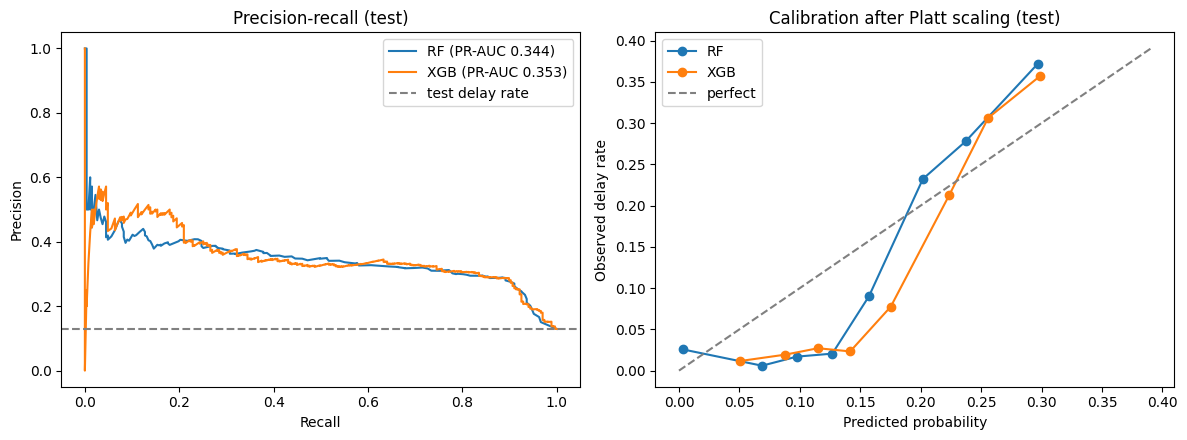

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
for name, r in R.items():
    p, rc, _ = precision_recall_curve(y_test, r["test_cal"])
    ax[0].plot(rc, p, label=f"{name} (PR-AUC {average_precision_score(y_test, r['test_cal']):.3f})")
    frac_pos, mean_pred = calibration_curve(y_test, r["test_cal"], n_bins=8, strategy="quantile")
    ax[1].plot(mean_pred, frac_pos, marker="o", label=name)
ax[0].axhline(y_test.mean(), color="gray", ls="--", label="test delay rate")
ax[0].set(title="Precision-recall (test)", xlabel="Recall", ylabel="Precision"); ax[0].legend()
mx = max(ax[1].get_xlim()[1], ax[1].get_ylim()[1])
ax[1].plot([0, mx], [0, mx], color="gray", ls="--", label="perfect")
ax[1].set(title="Calibration after Platt scaling (test)", xlabel="Predicted probability", ylabel="Observed delay rate"); ax[1].legend()
plt.tight_layout(); plt.show()

### Permutation importance (selected model, test set)

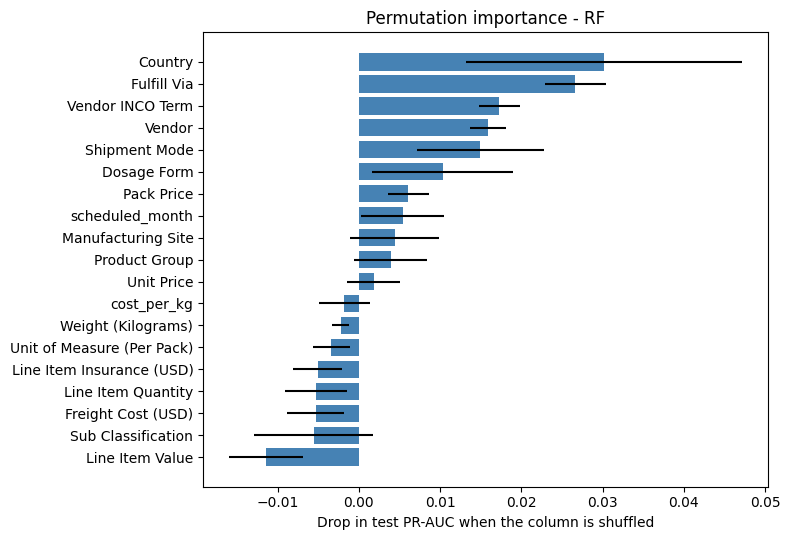

In [12]:
best_est = searches[best_name].best_estimator_
imp = permutation_importance(best_est, test_df[FEATURES], y_test, scoring="average_precision",
                             n_repeats=5, random_state=SEED, n_jobs=1)
imp_df = pd.DataFrame({"feature": FEATURES, "importance": imp.importances_mean, "std": imp.importances_std}) \
           .sort_values("importance")
plt.figure(figsize=(8, 5.5))
plt.barh(imp_df["feature"], imp_df["importance"], xerr=imp_df["std"], color="steelblue")
plt.xlabel("Drop in test PR-AUC when the column is shuffled")
plt.title(f"Permutation importance - {best_name}")
plt.tight_layout(); plt.show()

## 11. Chronological back-test

The single 80/20 split gives one estimate. This section checks that the result is stable over time: the tuned Random Forest is re-trained on **all months before** each window and scores the next 6-month window (three consecutive windows; the final six months in the data are not used). The threshold is the OOF threshold from Section 8.

The windows overlap the held-out test period of Section 4, so treat this as a robustness check across time, not as a second untouched test.

In [13]:
# Chronological validation using the latest available periods


validation_data = df.sort_values(
    "Scheduled Delivery Date"
).reset_index(drop=True).copy()

validation_data["year_month"] = (
    validation_data["Scheduled Delivery Date"]
    .dt.to_period("M")
    .astype(str)
)

available_months = validation_data["year_month"].drop_duplicates().tolist()

print("First month:", available_months[0])
print("Last month:", available_months[-1])
print("Number of months:", len(available_months))


# Use the Random Forest model selected by the notebook
best_rf_model = searches["RF"].best_estimator_

# Use the threshold selected from RF out-of-fold predictions (Section 8).
threshold = R["RF"]["thr"]

print("RF threshold:", round(threshold, 3))


# Use the final available months.
# Each test period has 6 months.
test_periods = [
    ("Period 1", -24, -18),
    ("Period 2", -18, -12),
    ("Period 3", -12, -6),
]


validation_results = []


for period_name, test_start, test_end in test_periods:

    # Skip if there are not enough months
    if len(available_months) < 24:
        print("Not enough months for:", period_name)
        continue

    train_months = available_months[:test_start]
    test_months = available_months[test_start:test_end]

    train_part = validation_data[
        validation_data["year_month"].isin(train_months)
    ].copy()

    test_part = validation_data[
        validation_data["year_month"].isin(test_months)
    ].copy()

    y_train_period = train_part["is_delayed"].astype(int)
    y_test_period = test_part["is_delayed"].astype(int)

    print("\n", period_name)
    print("Train:", train_months[0], "to", train_months[-1])
    print("Test:", test_months[0], "to", test_months[-1])
    print("Train rows:", len(train_part))
    print("Test rows:", len(test_part))
    print("Train delay rate:", round(y_train_period.mean(), 4))
    print("Test delay rate:", round(y_test_period.mean(), 4))

    # Both classes are required for these metrics
    if y_train_period.nunique() < 2:
        print("Skipped: training data has only one class.")
        continue

    if y_test_period.nunique() < 2:
        print("Skipped: test data has only one class.")
        continue

    # Train only on earlier data
    period_model = clone(best_rf_model)

    period_model.fit(
        train_part[FEATURES],
        y_train_period
    )

    # Predict the later period
    probabilities = period_model.predict_proba(
        test_part[FEATURES]
    )[:, 1]

    predictions = (
        probabilities >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test_period,
        predictions
    ).ravel()

    validation_results.append({
        "Period": period_name,
        "Train months": f"{train_months[0]} to {train_months[-1]}",
        "Test months": f"{test_months[0]} to {test_months[-1]}",
        "Train rows": len(train_part),
        "Test rows": len(test_part),
        "Train delay rate": round(y_train_period.mean(), 4),
        "Test delay rate": round(y_test_period.mean(), 4),
        "ROC-AUC": round(
            roc_auc_score(y_test_period, probabilities), 4
        ),
        "PR-AUC": round(
            average_precision_score(y_test_period, probabilities), 4
        ),
        "F1": round(
            f1_score(y_test_period, predictions, zero_division=0), 4
        ),
        "Precision": round(
            precision_score(y_test_period, predictions, zero_division=0), 4
        ),
        "Recall": round(
            recall_score(y_test_period, predictions, zero_division=0), 4
        ),
        "Alert rate": round(predictions.mean(), 4),
        "True positives": int(tp),
        "False positives": int(fp),
        "False negatives": int(fn),
        "Accuracy": round((tp + tn) / len(test_part), 4)
    })


validation_results = pd.DataFrame(validation_results)

print("\nFinal chronological validation results:")
display(validation_results)

First month: 2006-05
Last month: 2015-12
Number of months: 115
RF threshold: 0.14

 Period 1
Train: 2006-05 to 2013-11
Test: 2013-12 to 2014-05
Train rows: 7698
Test rows: 656
Train delay rate: 0.1056
Test delay rate: 0.2027

 Period 2
Train: 2006-05 to 2014-05
Test: 2014-06 to 2014-11
Train rows: 8354
Test rows: 886
Train delay rate: 0.1132
Test delay rate: 0.1354

 Period 3
Train: 2006-05 to 2014-11
Test: 2014-12 to 2015-05
Train rows: 9240
Test rows: 639
Train delay rate: 0.1154
Test delay rate: 0.1268

Final chronological validation results:


,Period,Train months,Test months,Train rows,Test rows,Train delay rate,Test delay rate,ROC-AUC,PR-AUC,F1,Precision,Recall,Alert rate,True positives,False positives,False negatives,Accuracy
0,Period 1,2006-05 to 2013-11,2013-12 to 2014-05,7698,656,0.1056,0.2027,0.7523,0.3564,0.4286,0.3377,0.5865,0.3521,78,153,55,0.6829
1,Period 2,2006-05 to 2014-05,2014-06 to 2014-11,8354,886,0.1132,0.1354,0.8566,0.3628,0.5000,0.3710,0.7667,0.2799,92,156,28,0.7923
2,Period 3,2006-05 to 2014-11,2014-12 to 2015-05,9240,639,0.1154,0.1268,0.8308,0.3367,0.4459,0.3036,0.8395,0.3505,68,156,13,0.7355


## 12. Power BI file

* Training rows: out-of-fold probability (never scored by a model that saw that row). Rows from folds where the model had little history carry `out_of_fold_low_history` so dashboards can filter them.
* Test rows: probability from the model trained on all training rows (`holdout_test`).
* The earliest shipments (first training window) have no out-of-fold score and stay in the file unscored.
* Probabilities are calibrated, so risk bands are real delay probabilities. Cut-offs come from the OOF score distribution of the skilled folds (bottom 40% = Low, next 30% = Moderate, next 20% = Elevated, top 10% = High).

In [15]:
r = R[best_name]
out = pd.concat([train_df, test_df], ignore_index=True)
out["delay_risk_prob"] = np.concatenate([r["oof_cal"], r["test_cal"]])

n_tr = len(train_df)
src = np.full(len(out), "holdout_test", dtype=object)
src[:n_tr] = np.where(r["fold_id"] < 0, "not_scored_initial_window",
              np.where(r["good"], "out_of_fold", "out_of_fold_low_history"))
out["score_source"] = src
out["predicted_delay"] = np.where(out["delay_risk_prob"].isna(), np.nan,
                                  (out["delay_risk_prob"] >= r["thr"]).astype(float))
out["model_used"] = best_name

q = np.quantile(r["oof_cal"][r["good"]], [0.40, 0.70, 0.90]).round(3)
RISK_BINS = [0.0, *q.tolist(), 1.0]
print("Risk band cut-offs (calibrated probability):", RISK_BINS)
out["risk_category"] = pd.cut(out["delay_risk_prob"], bins=RISK_BINS,
                              labels=["Low", "Moderate", "Elevated", "High"], include_lowest=True)

# Sanity check on rows with a reliable score: observed delay rate should rise from Low to High
ok = out["score_source"].isin(["out_of_fold", "holdout_test"])
chk = out[ok].groupby(["score_source", "risk_category"], observed=True)["is_delayed"] \
             .agg(shipments="size", observed_delay_rate="mean").round(3)
display(chk)

keep = ["Vendor", "Country", "Shipment Mode", "Product Group", "Scheduled Delivery Date",
        "Delivered to Client Date", "delay_days", "Freight Cost (USD)", "cost_per_kg", "Line Item Value",
        "is_delayed", "delay_risk_prob", "predicted_delay", "risk_category", "score_source", "model_used"]

powerbi = out[[c for c in keep if c in out.columns]]

POWERBI_DIR = Path("..") / "data" / "processed_data"
POWERBI_DIR.mkdir(parents=True, exist_ok=True)

POWERBI_PATH = POWERBI_DIR / "powerbi_delay_risk.csv"

powerbi.to_csv(POWERBI_PATH, index=False)

print(f"Saved {POWERBI_PATH} | shape: {powerbi.shape}")

Risk band cut-offs (calibrated probability): [0.0, 0.147, 0.208, 0.258, 1.0]


shipments  observed_delay_rate
score_source risk_category                                
holdout_test Low                 1135                0.021
             Moderate             333                0.156
             Elevated             343                0.283
             High                 254                0.370
out_of_fold  Low                 1669                0.078
             Moderate            1240                0.228
             Elevated             812                0.208
             High                 407                0.241

Saved ..\data\processed_data\powerbi_delay_risk.csv | shape: (10324, 16)


## 13. Save the model for the Streamlit app

Saves everything the what-if simulator (`app.py`) needs in one file: the selected pipeline, its calibrator, the alert threshold, the risk-band cut-offs, the feature lists, and small summaries of the data (category counts, numeric ranges, a background sample used for the "why this risk" bars). No raw data except the categorical columns and the delay flag is stored.

Run it after Section 12, then start the app with `streamlit run app.py`.

In [ ]:
r = R[best_name]

# Section 8 kept only the last model's calibrator in the loop variable, so re-fit the selected model's
# calibrator with the same recipe and check it reproduces the saved test probabilities.
platt_final = LogisticRegression(C=1e6).fit(to_logit(r["oof_raw"][r["good"]]), y_train[r["good"]])
assert np.allclose(platt_final.predict_proba(to_logit(r["test_raw"]))[:, 1], r["test_cal"]), "calibrator mismatch"

cat_features = [c for c in FEATURES if c in cat_all]
num_features = [c for c in FEATURES if c not in cat_all]

numeric_stats = {}
for c in num_features:
    s = df[c].astype(float)
    numeric_stats[c] = {"min": float(s.min()), "p01": float(s.quantile(0.01)), "median": float(s.median()),
                        "p99": float(s.quantile(0.99)), "max": float(s.max()), "has_missing": bool(s.isna().any())}

artifacts = {
    "model_name": best_name,
    "pipeline": best_est,                        # fitted on the training rows only
    "calibrator": platt_final,
    "threshold": float(r["thr"]),
    "risk_bins": [float(b) for b in RISK_BINS],
    "features": list(FEATURES),
    "cat_features": cat_features,
    "num_features": num_features,
    "numeric_stats": numeric_stats,
    "history": df[cat_features + ["is_delayed"]].reset_index(drop=True),
    "background": train_df[FEATURES].sample(min(200, len(train_df)), random_state=SEED).reset_index(drop=True),
    "base_rate": float(y_train.mean()),
    "metrics": {"test": results.loc[(best_name, "TEST (held-out)")].to_dict(),
                "baseline_rmse_test": rmse(y_test, np.full(len(y_test), base_rate)),
                "test_delay_rate": float(y_test.mean())},
    "train_period": (str(train_df["Scheduled Delivery Date"].min().date()),
                     str(train_df["Scheduled Delivery Date"].max().date())),
    "n_train": int(len(train_df)),
    "versions": {"scikit-learn": sklearn.__version__, "xgboost": xgboost.__version__},
}

MODEL_DIR = Path("..") / "models_artifacts"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODEL_DIR / "delay_model.joblib"

joblib.dump(artifacts, MODEL_PATH, compress=3)

size_kb = MODEL_PATH.stat().st_size / 1024

print(
    f"Saved {MODEL_PATH} ({size_kb:,.0f} KB) | "
    f"model: {best_name} | "
    f"threshold {r['thr']:.2f} | "
    f"{len(FEATURES)} features"
)

Saved ..\models\delay_model.joblib (9,438 KB) | model: RF | threshold 0.14 | 19 features


## 14. Summary (results of the run saved in this notebook)

* **Selected model:** Random Forest (best out-of-fold PR-AUC 0.234 vs 0.216 for XGBoost, chosen without using the test set).
* **Test (newest 20% of shipments, used once):** ROC-AUC 0.81, PR-AUC 0.34 (delay rate is 12.9%), **RMSE 0.316 vs 0.336 for always predicting the base rate** (Brier 0.100). At the OOF-chosen threshold 0.14: recall 0.93, precision 0.25, F1 0.39, 49% of shipments flagged.
* **XGBoost on test:** ROC-AUC 0.80, PR-AUC 0.34, RMSE 0.320, but at its own threshold (0.12) it flags 74% of shipments (F1 0.29), so Random Forest is the better operational choice.
* **Chronological back-test (three 6-month windows):** ROC-AUC 0.76-0.86, PR-AUC 0.34-0.37, F1 0.45-0.49, recall 0.62-0.85, so the result is not an artefact of one split.

**Honest caveats**

* The signal is modest: RMSE improves by about 6% over the base-rate baseline, and precision is low because only ~13% of shipments are delayed.
* The delay pattern drifted strongly over time. Models trained on the earliest data predict the next period at roughly random level (fold ROC-AUC 0.36-0.52 for the first two folds), which is why calibration and the threshold use only the later, skilled folds.
* Scores for early-period training rows are flagged `out_of_fold_low_history`; the first window is left unscored.
* Out-of-fold risk bands are not as cleanly ordered as test bands (Moderate vs Elevated overlap); on the test set the observed delay rate rises 2% -> 18% -> 30% -> 35% from Low to High.
* Previous random-split scores (F1 ~0.43-0.45) are not comparable: they mixed past and future rows.